In [ ]:
"https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"

## Basic DataFrame

Consider the following Python dictionary data and Python list labels:

```
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
```
```
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']
```

### `Q-1:`
i. Create a DataFrame birds from the above dictionary data which has the index labels.

ii. Display basic information about the dataFrame.

iii. Show Alternate rows of the dataframe.

In [165]:
import numpy as np
import pandas as pd

In [166]:
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5],
        'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no', 'yes']}

labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']

# i. create dataframe with index labels
df = pd.DataFrame(data, index=labels)
print("i. DataFrame:\n", df)
print(35*"-")

# ii. basic information
print("\nii. Basic Info:")
print(df.info())
print("\nShape    :", df.shape)
print("Columns  :", df.columns.tolist())
print("Describe :\n", df.describe())
print(30*"-")
# iii. alternate rows (0, 2, 4, ...)
print("\niii. Alternate rows:\n", df[::2])



i. DataFrame:
         birds  age  visits priority
a      Cranes  3.5       2      yes
b      Cranes  4.0       4      yes
c     plovers  1.5       3       no
d  spoonbills  NaN       4      NaN
e  spoonbills  6.0       3       no
f      Cranes  3.0       4       no
g     plovers  5.5       2       no
h      Cranes  NaN       2      yes
i  spoonbills  8.0       3       no
j  spoonbills  4.0       2       no
k      Cranes  3.5       2      yes
-----------------------------------

ii. Basic Info:
<class 'pandas.DataFrame'>
Index: 11 entries, a to k
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   birds     11 non-null     str    
 1   age       9 non-null      float64
 2   visits    11 non-null     int64  
 3   priority  10 non-null     str    
dtypes: float64(1), int64(1), str(2)
memory usage: 440.0+ bytes
None

Shape    : (11, 4)
Columns  : ['birds', 'age', 'visits', 'priority']
Describe :
             age     visits
cou

### `Q-2:`
i. Show only rows [1st, 3rd, 7th] from columns ['bird', 'age']

ii. Select rows where the number of visits is less than 4.

In [167]:
# i. rows 1st, 3rd, 7th from columns birds and age
print("i. Rows [1,3,7] — birds & age:")
print(df.iloc[[0, 2, 6]][['birds', 'age']])
print(30*"-")
# ii. rows where visits < 4
print("\nii. Rows where visits < 4:")
print(df[df['visits'] < 4])

i. Rows [1,3,7] — birds & age:
     birds  age
a   Cranes  3.5
c  plovers  1.5
g  plovers  5.5
------------------------------

ii. Rows where visits < 4:
        birds  age  visits priority
a      Cranes  3.5       2      yes
c     plovers  1.5       3       no
e  spoonbills  6.0       3       no
g     plovers  5.5       2       no
h      Cranes  NaN       2      yes
i  spoonbills  8.0       3       no
j  spoonbills  4.0       2       no
k      Cranes  3.5       2      yes


### `Q-3:`
i. Select all rows with nan values in age and visits column.

ii. Fill nan with respective series mode value.

In [168]:
# i. rows with NaN in age or visits
print("i. Rows with NaN in age or visits:")
print(df[df[['age', 'visits']].isna().any(axis=1)])
print(35*"-")
# ii. fill NaN with mode of each column
age_mode      = df['age'].mode()[0]
priority_mode = df['priority'].mode()[0]

df['age']      = df['age'].fillna(age_mode)
df['priority'] = df['priority'].fillna(priority_mode)

print("\nii. After filling NaN with mode:")
print(df)
print("\nAge mode used     :", age_mode)
print("Priority mode used:", priority_mode)

i. Rows with NaN in age or visits:
        birds  age  visits priority
d  spoonbills  NaN       4      NaN
h      Cranes  NaN       2      yes
-----------------------------------

ii. After filling NaN with mode:
        birds  age  visits priority
a      Cranes  3.5       2      yes
b      Cranes  4.0       4      yes
c     plovers  1.5       3       no
d  spoonbills  3.5       4       no
e  spoonbills  6.0       3       no
f      Cranes  3.0       4       no
g     plovers  5.5       2       no
h      Cranes  3.5       2      yes
i  spoonbills  8.0       3       no
j  spoonbills  4.0       2       no
k      Cranes  3.5       2      yes

Age mode used     : 3.5
Priority mode used: no


### `Q-4`
i. Find the total number of visits of the bird Cranes

ii. Find the number of each type of birds in dataframe.

iii. Print no of duplicate rows

iv. Drop Duplicates rows and make this changes permanent. Show dataframe after changes.

In [169]:
# i. total visits of Cranes
print("i. Total visits of Cranes:")
print(df[df['birds'] == 'Cranes']['visits'].sum())
print(30*"-")
# ii. count of each bird type
print("\nii. Count of each bird type:")
print(df['birds'].value_counts())
print(30*"-")

# iii. number of duplicate rows
print("\niii. Number of duplicate rows:")
print(df.duplicated().sum())
print(30*"-")


print("\niv. After dropping duplicates:")
df = df.drop_duplicates()
print(df)

i. Total visits of Cranes:
14
------------------------------

ii. Count of each bird type:
birds
Cranes        5
spoonbills    4
plovers       2
Name: count, dtype: int64
------------------------------

iii. Number of duplicate rows:
2
------------------------------

iv. After dropping duplicates:
        birds  age  visits priority
a      Cranes  3.5       2      yes
b      Cranes  4.0       4      yes
c     plovers  1.5       3       no
d  spoonbills  3.5       4       no
e  spoonbills  6.0       3       no
f      Cranes  3.0       4       no
g     plovers  5.5       2       no
i  spoonbills  8.0       3       no
j  spoonbills  4.0       2       no


## Question on IPL Data

IPL Data Link :  https://drive.google.com/file/d/1yKVUuexl6lIKuFQy7uIPgDgXhJ0L4SIg/view?usp=share_link

https://www.kaggle.com/datasets/vora1011/ipl-2008-to-2021-all-match-dataset?select=IPL_Matches_2008_2022.csv

Download ipl matches 2008-2022 file.

### `Q-5:` In IPL matches dataset some teams name has changed.
You will have to consider them as same.
```
'Delhi Capitals' formerly as 'Delhi Daredevils'
'Punjab Kings' formerly as 'Kings XI Punjab'
'Rising Pune Supergiant' formerly as 'Rising Pune Supergiants'
```
You need to make changes accordingly. Consider current name for each teams.

Be careful Gujrat Titans and Gujrat Lions are different teams.

In [ ]:
import pandas as pd

df = pd.read_csv("ipl-matches.csv")
print(df.shape)

# Display all dataset column names in list format
print(df.columns.tolist())

(950, 20)
['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2', 'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam', 'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players', 'Team2Players', 'Umpire1', 'Umpire2']


In [171]:
# old name → new name mapping

df = pd.read_csv("ipl-matches.csv")
rename_map = {
    'Delhi Daredevils'       : 'Delhi Capitals',
    'Kings XI Punjab'        : 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
}

# apply renaming to all team columns
for col in ['Team1', 'Team2', 'TossWinner', 'WinningTeam']:
    df[col] = df[col].replace(rename_map)

# verify — check old names no longer exist
print("Old names remaining:")
for old in rename_map.keys():
    count = (df[['Team1','Team2','TossWinner','WinningTeam']] == old).sum().sum()
    print(f"  '{old}' : {count}")

# verify new names exist
print("\nNew names count (Team1 + Team2):")
all_teams = pd.concat([df['Team1'], df['Team2']]).value_counts()
all_teams
for new in rename_map.values():
    print(f"  '{new}' : {all_teams.get(new, 0)}")

Old names remaining:
  'Delhi Daredevils' : 0
  'Kings XI Punjab' : 0
  'Rising Pune Supergiants' : 0

New names count (Team1 + Team2):
  'Delhi Capitals' : 224
  'Punjab Kings' : 218
  'Rising Pune Supergiant' : 30


### `Q-6` Write a code which can display the bar chart of top 5 teams who have played maximum number of matches in the IPL.
>  Hint: Be careful the data is divided in 2 different cols(Team 1 and Team 2)


Top 5 teams:
 Mumbai Indians                 231
Royal Challengers Bangalore    226
Delhi Capitals                 224
Kolkata Knight Riders          223
Punjab Kings                   218
Name: count, dtype: int64


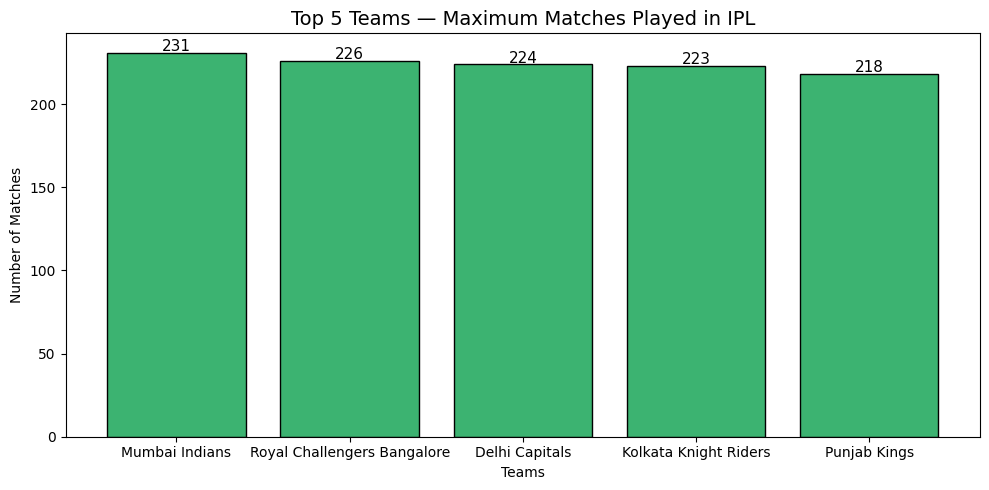

In [184]:
import matplotlib.pyplot as plt


# combine Team1 and Team2 into one series
all_teams = pd.concat([df['Team1'], df['Team2']])

# count matches per team and get top 5
top5 = all_teams.value_counts().head(5)
print("Top 5 teams:\n", top5)

# bar chart
plt.figure(figsize=(10, 5))
plt.bar(top5.index, top5.values, color='mediumseagreen', edgecolor='black')

plt.title('Top 5 Teams — Maximum Matches Played in IPL', fontsize=14)
plt.xlabel('Teams')
plt.ylabel('Number of Matches')

# value on top of each bar
for i, val in enumerate(top5.values):
    plt.text(i, val + 1, str(val), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("top_5_teams_matches.png", dpi=300, bbox_inches='tight')
plt.show()

### `Q-7:` Player who got Most no. of player of the match award playing against Mumbai Indians.
> Just for this question assume player of the match award is given to players from winning team. Although this is true in most of the cases.


In [173]:
# matches where Mumbai Indians played (either Team1 or Team2)
mi_matches = df[(df['Team1'] == 'Mumbai Indians') | (df['Team2'] == 'Mumbai Indians')]

# matches where Mumbai Indians LOST (player of match is from winning team)
mi_lost = mi_matches[mi_matches['WinningTeam'] != 'Mumbai Indians']

# top player of the match against MI
top_player = mi_lost['Player_of_Match'].value_counts().head(10)

print("Players with most POTM awards against Mumbai Indians:\n")
print(top_player)
print(f"\nTop Player: {top_player.index[0]} ({top_player.iloc[0]} times)")

Players with most POTM awards against Mumbai Indians:

Player_of_Match
KL Rahul         4
SPD Smith        4
SK Raina         4
JC Buttler       3
A Mishra         3
A Nehra          3
JH Kallis        3
V Sehwag         3
CH Gayle         3
KC Sangakkara    3
Name: count, dtype: int64

Top Player: KL Rahul (4 times)


### `Q-8:` Team1 vs Team2 Dashbord
Create a function which will take two string(name of two teams) as input. Show win Loss record between them and player getting most player of the match award in matches between these two teams.
```
team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')
```

In [180]:
def team1_vs_team2(t1, t2):
    # Filter matches where the two teams played against each other
    match_mask = ((df['Team1'] == t1) & (df['Team2'] == t2)) | ((df['Team1'] == t2) & (df['Team2'] == t1))
    h2h_matches = df[match_mask]
    
    total_played = len(h2h_matches)
    
    if total_played == 0:
        print(f"No matches found between '{t1}' and '{t2}'. Check for typos or old team names!")
        return

    # Calculate wins for both teams
    t1_wins = len(h2h_matches[h2h_matches['WinningTeam'] == t1])
    t2_wins = len(h2h_matches[h2h_matches['WinningTeam'] == t2])
    no_result = total_played - (t1_wins + t2_wins)
    
    # Find the player(s) with the most Player of the Match awards in these fixtures
    pom_counts = h2h_matches['Player_of_Match'].value_counts()
    
    if not pom_counts.empty:
        max_awards = pom_counts.max()
        # Get all players who share the maximum count (handles ties gracefully)
        top_players = pom_counts[pom_counts == max_awards].index.tolist()
        top_players_str = ", ".join(top_players)

        pom_info = f"{top_players_str} ({max_awards} times)"
    else:
        pom_info = "None"

    # Print the Dashboard
    print(f"=== Head-to-Head Dashboard ===")
    print(f"Matchup: {t1} vs {t2}")
    print(f"Total Matches Played: {total_played}")
    print("-" * 30)
    print(f"{t1} Wins: {t1_wins}")
    print(f"{t2} Wins: {t2_wins}")
    if no_result > 0:
        print(f"No Result/Tied: {no_result}")
    print("-" * 30)
    print(f"Most Player of the Match: {pom_info}")
    print("==============================")



In [181]:
# Example execution
team1_vs_team2('Kolkata Knight Riders', 'Chennai Super Kings')

=== Head-to-Head Dashboard ===
Matchup: Kolkata Knight Riders vs Chennai Super Kings
Total Matches Played: 26
------------------------------
Kolkata Knight Riders Wins: 9
Chennai Super Kings Wins: 17
------------------------------
Most Player of the Match: RA Jadeja (3 times)


### `Q-9:` Find out the top 7 cities where the matches of Kolkata Knight Riders are played frequently and plot the result as bar chart.

*`.plot(kind = "bar")` can help you to plot the bar chart. Also you can learn more about this method from [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)*



In [185]:
# Function to show top cities where a team played matches
def top_cities(team, n=7):

    # Filter matches of the given team
    matches = df[(df['Team1'] == team) | (df['Team2'] == team)]

    # Get top n cities with the most matches
    top_cities = matches['City'].value_counts().head(n)
    print(f"Top {n} Cities for {team}:\n", top_cities)

    # Create a bar chart
    top_cities.plot(kind='bar',
                    figsize=(10, 6),
                    color='purple',
                    edgecolor='black')

    # Add chart title and axis labels
    plt.title(f'Top {n} Cities — {team} Matches', fontsize=14)
    plt.xlabel('City')
    plt.ylabel('Number of Matches')

    # Rotate city names for better readability
    plt.xticks(rotation=45)

    # Display match count above each bar
    for i, val in enumerate(top_cities.values):
        plt.text(i, val + 0.3, str(val), ha='center', fontsize=11)

    # Adjust layout and show the chart
    plt.tight_layout()
    plt.savefig(f"{team}_top_{n}_cities.png", dpi=300, bbox_inches='tight')
    plt.show()


Top 7 Cities for Kolkata Knight Riders:
 City
Kolkata      74
Mumbai       23
Abu Dhabi    14
Chennai      12
Bangalore    11
Delhi        10
Pune          9
Name: count, dtype: int64


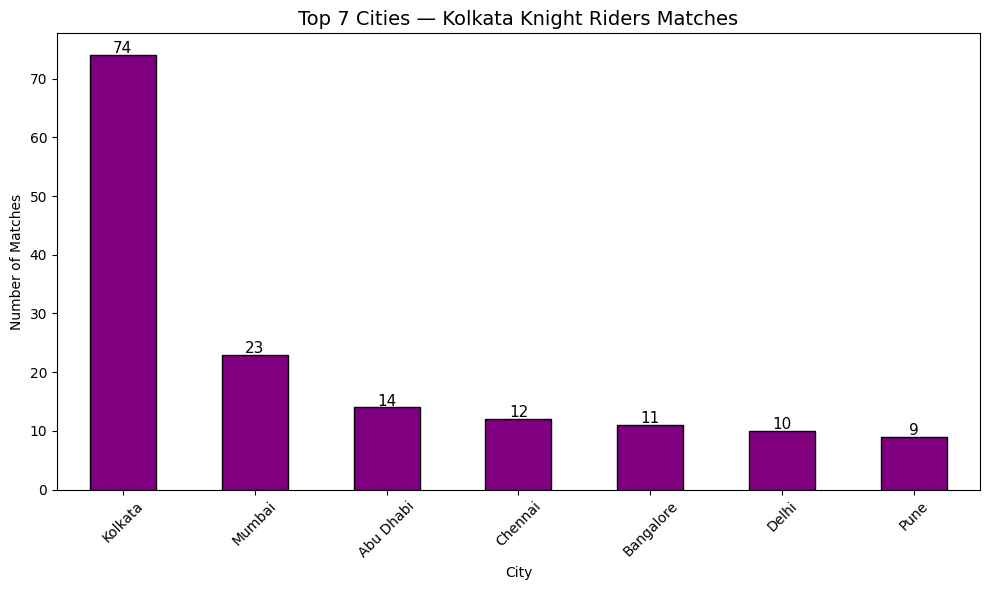

Top 5 Cities for Mumbai Indians:
 City
Mumbai       90
Delhi        13
Chennai      13
Kolkata      13
Abu Dhabi    12
Name: count, dtype: int64


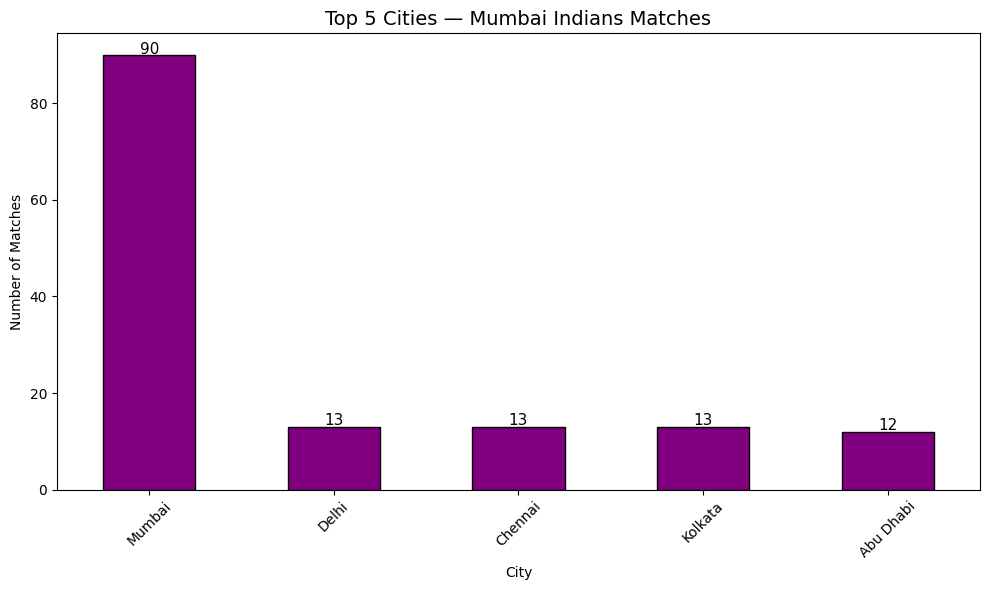

In [186]:

# Function calls
top_cities('Kolkata Knight Riders', n=7)
top_cities('Mumbai Indians', n=5)   # Use any team name

### `Q-10:` Find out the average margin for the team Mumbai Indians for only the season 2011.

In [176]:
# filter MI matches in season 2011
mi_2011 = df[(df['Season'] == "2011") & 
             ((df['Team1'] == 'Mumbai Indians') | 
              (df['Team2'] == 'Mumbai Indians'))]

# average margin
avg_margin = mi_2011['Margin'].mean()

print(f"Total matches played by MI in 2011 : {len(mi_2011)}")
print(f"Average Margin                     : {avg_margin:.2f}")

Total matches played by MI in 2011 : 16
Average Margin                     : 19.25
